# ThyroML: three-class thyroid function classification (research prototype)

ThyroML is an **experimental machine-learning research project**. It is **not a medical diagnostic device** and has not been clinically validated.

**Task.** Classify archived thyroid-test records into three *derived* classes: **Hyperthyroid**, **Euthyroid-sick**, **Euthyroid**.

**Important.** The source dataset (UCI Thyroid Disease, file `thyroid0387`, Garvan Institute, 1984-1987) does **not** contain these three labels natively. It contains diagnosis *codes* (letters such as `A`, `K`, `-`, `GK`). ThyroML derives its target from those codes with a documented mapping (Section 5). Throughout this notebook, **source label** means the original diagnosis code and **derived label** means the ThyroML class.

Workflow: train / validation (CV folds) / test. Model selection uses stratified, grouped k-fold cross-validation on the training portion only; the held-out test set is used once, in Section 13.

## 1 Configuration
All seeds, paths and constants live here. Every estimator, split and resampling routine receives `SEED` (or a seed derived from it in this cell) explicitly.

In [1]:
import time
NOTEBOOK_START = time.perf_counter()

from pathlib import Path

SEED = 42                                   # single global seed, passed explicitly everywhere
HOLDOUT_FOLDS = 5                           # test = 1 of 5 stratified, grouped folds (about 20 %)
CV_FOLDS = 5                                # validation stage: stratified, grouped 5-fold CV
CV_REPEATS = 3                              # repeated with different shuffles for model comparison
CV_REPEAT_SEEDS = [SEED + i for i in range(1, CV_REPEATS + 1)]
N_BOOTSTRAP = 2000                          # bootstrap resamples for test-set confidence intervals
N_PERM_REPEATS = 20                         # permutation-importance repeats
AGE_MAX_PLAUSIBLE = 120                     # ages above this are data-entry errors -> NaN
N_JOBS = -1                                 # CPU parallelism (no GPU is used)

# Data source: UCI Thyroid Disease (thyroid0387), acquired through a verbatim Kaggle mirror
KAGGLE_HANDLE = "abdelazizsami/thyroid-disease"
DATA_FILE = "thyroid0387.data"
NAMES_FILE = "thyroid0387.names"
# SHA-256 of the files inside the official UCI archive https://archive.ics.uci.edu/static/public/102/thyroid+disease.zip
# (archive downloaded 2026-10-08; archive SHA-256 a0982569a7442c03a20815db58f271245e7a111b10ac46f6c6b5fa6feee4c1f4).
EXPECTED_SHA256 = {
    DATA_FILE: "4a20d104d4607afd7b1a477af5aa4381a2027f36cc7027f44bc2bd5a50c6724d",
    NAMES_FILE: "4f0439617f6e7b456e681ff188ab0800381fcad5d3c3a5c48518f33a19f5b175",
}

# Derived target: source diagnosis code -> ThyroML class. Everything else is excluded.
SOURCE_TO_DERIVED = {
    "A": "Hyperthyroid",    # hyperthyroid
    "B": "Hyperthyroid",    # T3 toxic
    "C": "Hyperthyroid",    # toxic goitre
    "D": "Hyperthyroid",    # secondary toxic
    "K": "Euthyroid-sick",  # concurrent non-thyroidal illness
    "-": "Euthyroid",       # no condition requiring comment
}
CLASS_ORDER = ["Euthyroid", "Euthyroid-sick", "Hyperthyroid"]
MINORITY_CLASSES = ["Hyperthyroid", "Euthyroid-sick"]
CLASS_COLORS = {"Euthyroid": "#2a78d6", "Euthyroid-sick": "#eb6834", "Hyperthyroid": "#1baf7a"}

REPO_DIR = Path.cwd().resolve()
assert (REPO_DIR / "ThyroML.ipynb").exists(), "Run the notebook from the repository root."
ARTIFACTS = REPO_DIR / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
FIG_DPI = 100
print("Seed:", SEED, "| CV repeat seeds:", CV_REPEAT_SEEDS, "| artifacts ->", ARTIFACTS.name + "/")

Seed: 42 | CV repeat seeds: [43, 44, 45] | artifacts -> artifacts/


## 2 Imports
Package versions and hardware are recorded for reproducibility. The data are small and tabular, so everything runs on the CPU.

In [2]:
import hashlib, json, os, platform, re, string, sys, warnings

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, scipy, scipy.stats, joblib, kagglehub, lightgbm
from IPython.display import Image, display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import MissingIndicator, SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, balanced_accuracy_score,
                             confusion_matrix, f1_score, make_scorer, precision_recall_curve,
                             precision_recall_fscore_support, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, cross_validate
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)
sns.set_theme(style="whitegrid", context="notebook")

VERSIONS = {
    "python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__, "scipy": scipy.__version__, "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__, "lightgbm": lightgbm.__version__, "joblib": joblib.__version__,
    "kagglehub": kagglehub.__version__,
}
HARDWARE = {"platform": platform.platform(), "processor": platform.processor(),
            "logical_cpus": os.cpu_count(), "compute": "CPU only (GPU not used: small tabular data)"}
print(json.dumps({"versions": VERSIONS, "hardware": HARDWARE}, indent=1))

{
 "versions": {
  "python": "3.11.9",
  "numpy": "2.4.6",
  "pandas": "3.0.6",
  "scikit-learn": "1.9.1",
  "scipy": "1.17.1",
  "matplotlib": "3.11.2",
  "seaborn": "0.13.2",
  "lightgbm": "4.7.0",
  "joblib": "1.6.0",
  "kagglehub": "1.0.2"
 },
 "hardware": {
  "platform": "Windows-10-10.0.26300-SP0",
  "processor": "Intel64 Family 6 Model 198 Stepping 2, GenuineIntel",
  "logical_cpus": 24,
  "compute": "CPU only (GPU not used: small tabular data)"
 }
}


## 3 Data acquisition
**Primary source:** Quinlan, R. (1986). *Thyroid Disease* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5D010 (https://archive.ics.uci.edu/dataset/102/thyroid+disease), licensed CC BY 4.0. The file used is `thyroid0387.data` (9172 records, Garvan Institute, Sydney, 1984 to early 1987).

**Acquisition:** the Kaggle mirror `abdelazizsami/thyroid-disease`, which holds the raw UCI archive files verbatim, is downloaded with `kagglehub` into the local kagglehub cache (outside the repository). The SHA-256 checksums below are asserted to equal those of the same files in the official UCI archive, so the mirror is byte-identical to the primary source.

In [3]:
data_dir = Path(kagglehub.dataset_download(KAGGLE_HANDLE))

def sha256_of(path):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

checksums = pd.DataFrame([
    {"file": name, "bytes": (data_dir / name).stat().st_size, "sha256": sha256_of(data_dir / name),
     "matches_official_UCI": sha256_of(data_dir / name) == EXPECTED_SHA256[name]}
    for name in (DATA_FILE, NAMES_FILE)
])
assert checksums["matches_official_UCI"].all(), "Downloaded file differs from the official UCI file"
checksums.to_csv(ARTIFACTS / "data_checksums.csv", index=False)
print("Data cached in the kagglehub cache (outside the repository).")
checksums

Data cached in the kagglehub cache (outside the repository).


,file,bytes,sha256,matches_official_UCI
0,thyroid0387.data,772576,4a20d104d4607afd7b1a477af5aa4381a2027f36cc7027...,True
1,thyroid0387.names,2567,4f0439617f6e7b456e681ff188ab0800381fcad5d3c3a5...,True


In [4]:
# Parse the raw records: 29 comma-separated attributes, then "<diagnosis>[<record id>]"; '?' marks missing.
RAW_COLUMNS = [
    "age", "sex", "on_thyroxine", "query_on_thyroxine", "on_antithyroid_medication", "sick", "pregnant",
    "thyroid_surgery", "I131_treatment", "query_hypothyroid", "query_hyperthyroid", "lithium", "goitre",
    "tumor", "hypopituitary", "psych", "TSH_measured", "TSH", "T3_measured", "T3", "TT4_measured", "TT4",
    "T4U_measured", "T4U", "FTI_measured", "FTI", "TBG_measured", "TBG", "referral_source",
]
LINE_RE = re.compile(r"^(?P<attrs>.*),(?P<diagnosis>[^,\[]*)\[(?P<record_id>\d+)\]$")

records, unparsed = [], []
for line_no, line in enumerate((data_dir / DATA_FILE).read_text(encoding="ascii").splitlines(), start=1):
    m = LINE_RE.match(line.strip())
    attrs = m.group("attrs").split(",") if m else []
    if not m or len(attrs) != len(RAW_COLUMNS):
        unparsed.append(line_no)
        continue
    records.append(attrs + [m.group("diagnosis"), m.group("record_id")])

raw = pd.DataFrame(records, columns=RAW_COLUMNS + ["diagnosis", "record_id"])
print(f"Parsed records: {len(raw)} | unparseable lines: {len(unparsed)}")

Parsed records: 9172 | unparseable lines: 0


## 4 Dataset inspection
Files and their roles, columns, missing-value markers, source diagnosis codes, implausible values and duplicates. Nothing is modified in this section.

In [5]:
def file_role(name):
    if name in (DATA_FILE, NAMES_FILE):
        return "USED: thyroid0387 records / documentation"
    if name.startswith(("allbp", "allhyper", "allhypo", "allrep", "dis", "sick.")):
        return "not used: earlier task-specific subset of the Garvan data (2800 train + 972 test)"
    if name.startswith("ann-"):
        return "not used: preprocessed 3-class hypo/hyper variant (Schiffmann et al.)"
    if name.startswith("new-thyroid"):
        return "not used: different, small dataset (215 records)"
    if name.startswith(("hypothyroid", "sick-euthyroid")):
        return "not used: older binary-task files"
    return "not used: documentation / costs / theory"

files = pd.DataFrame([{"file": p.name + ("/" if p.is_dir() else ""),
                       "bytes": p.stat().st_size if p.is_file() else pd.NA,
                       "role": file_role(p.name)} for p in sorted(data_dir.iterdir())])
files["bytes"] = files["bytes"].astype("Int64")
print(files.to_string(index=False))

                file  bytes                                                                              role
          allbp.data 242460 not used: earlier task-specific subset of the Garvan data (2800 train + 972 test)
         allbp.names    866 not used: earlier task-specific subset of the Garvan data (2800 train + 972 test)
          allbp.test  84030 not used: earlier task-specific subset of the Garvan data (2800 train + 972 test)
       allhyper.data 240433 not used: earlier task-specific subset of the Garvan data (2800 train + 972 test)
      allhyper.names    861 not used: earlier task-specific subset of the Garvan data (2800 train + 972 test)
       allhyper.test  83585 not used: earlier task-specific subset of the Garvan data (2800 train + 972 test)
        allhypo.data 243239 not used: earlier task-specific subset of the Garvan data (2800 train + 972 test)
       allhypo.names    894 not used: earlier task-specific subset of the Garvan data (2800 train + 972 test)
        al

In [6]:
print("Shape:", raw.shape, "| unique record ids:", raw["record_id"].nunique())
print("All raw columns are text at this point; '?' marks a missing value.")
raw.head(3)

Shape: (9172, 31) | unique record ids: 9172
All raw columns are text at this point; '?' marks a missing value.


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,goitre,tumor,hypopituitary,...,TSH_measured,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,diagnosis,record_id
0,29,F,f,f,f,f,f,f,f,t,f,f,f,f,f,...,t,0.3,f,?,f,?,f,?,f,?,f,?,other,-,840801013
1,29,F,f,f,f,f,f,f,f,f,f,f,f,f,f,...,t,1.6,t,1.9,t,128,f,?,f,?,f,?,other,-,840801014
2,41,F,f,f,f,f,f,f,f,f,t,f,f,f,f,...,f,?,f,?,f,?,f,?,f,?,t,11,other,-,840801042


In [7]:
qmarks = (raw == "?").sum()
missing_table = pd.DataFrame({"n_missing('?')": qmarks, "pct": (100 * qmarks / len(raw)).round(1)})
print(missing_table[missing_table["n_missing('?')"] > 0].to_string())
# *_measured flags are redundant with missingness of the corresponding value
for col in ["TSH", "T3", "TT4", "T4U", "FTI", "TBG"]:
    same = ((raw[f"{col}_measured"] == "t") == (raw[col] != "?")).all()
    print(f"{col}_measured == ({col} is present): {same}")

     n_missing('?')   pct
sex             307   3.3
TSH             842   9.2
T3             2604  28.4
TT4             442   4.8
T4U             809   8.8
FTI             802   8.7
TBG            8823  96.2
TSH_measured == (TSH is present): True
T3_measured == (T3 is present): True
TT4_measured == (TT4 is present): True
T4U_measured == (T4U is present): True
FTI_measured == (FTI is present): True
TBG_measured == (TBG is present): True


In [8]:
# Source diagnosis codes (letters per thyroid0387.names; 'X|Y' = consistent with X but more likely Y)
code_counts = raw["diagnosis"].value_counts()
print(f"{code_counts.size} distinct source codes")
print(code_counts.to_frame("n").T.to_string())
expected = {"A": 147, "B": 21, "C": 6, "D": 8, "K": 436, "-": 6771}
observed = {c: int(code_counts.get(c, 0)) for c in expected}
print("Expected vs observed counts for the mapped codes:", observed)
assert observed == expected

32 distinct source codes
diagnosis     -    K    G    I    F    R    A    L    M    N   S  GK  AK   J   B  MK   Q   O  C|I  KJ  GI  H|K  D  FK  C  P  MI  LJ  GKJ  OI  D|R  E
n          6771  436  359  346  233  196  147  115  111  110  85  49  46  30  21  16  14  14   12  11  10    8  8   6  6  5   2   1    1   1    1  1
Expected vs observed counts for the mapped codes: {'A': 147, 'B': 21, 'C': 6, 'D': 8, 'K': 436, '-': 6771}


In [9]:
num_cols = ["age", "TSH", "T3", "TT4", "T4U", "FTI", "TBG"]
num_view = raw[num_cols].replace("?", np.nan).astype(float)
print(num_view.describe().T.round(3).to_string())
print("\nAges above", AGE_MAX_PLAUSIBLE, ":", sorted(num_view.loc[num_view["age"] > AGE_MAX_PLAUSIBLE, "age"].astype(int).tolist()))
print("Largest TSH values:", sorted(num_view["TSH"].dropna().nlargest(5).tolist()))
print("Exact duplicate records (all 29 attributes + code, ignoring record id):",
      int(raw.drop(columns="record_id").duplicated().sum()))
print("Pregnant and male:", int(((raw["pregnant"] == "t") & (raw["sex"] == "M")).sum()))

      count     mean       std    min    25%     50%      75%       max
age  9172.0   73.556  1183.977  1.000  37.00   55.00   68.000  65526.00
TSH  8330.0    5.218    24.184  0.005   0.46    1.40    2.700    530.00
T3   6568.0    1.971     0.888  0.050   1.50    1.90    2.300     18.00
TT4  8730.0  108.700    37.523  2.000  87.00  104.00  126.000    600.00
T4U  8363.0    0.976     0.200  0.170   0.86    0.96    1.065      2.33
FTI  8370.0  113.641    41.552  1.400  93.00  109.00  128.000    881.00
TBG   349.0   29.870    21.081  0.100  21.00   26.00   31.000    200.00

Ages above 120 : [455, 65511, 65512, 65526]
Largest TSH values: [472.0, 478.0, 494.0, 500.0, 530.0]
Exact duplicate records (all 29 attributes + code, ignoring record id): 10
Pregnant and male: 0


## 5 Cleaning and derived target construction
### 5.1 Exclusion rules (applied in this order, all deterministic and applied before any split)
1. **Mapping.** Keep only records whose source code is exactly one of `A`, `B`, `C`, `D` (-> Hyperthyroid), `K` (-> Euthyroid-sick) or `-` (-> Euthyroid).
   * *Excluded: multiple concurrent codes* (e.g. `AK`, `GK`, `KJ`, `MK`): the record carries more than one condition, so it has no single derived class.
   * *Excluded: ambiguous `X|Y` codes* (e.g. `C|I`, `D|R`, `H|K`): "consistent with X, but more likely Y".
   * *Excluded: single codes outside the target scope* (hypothyroid `E-H`, binding protein `I-J`, replacement therapy `L-N`, antithyroid treatment `O-Q`, miscellaneous `R-T`).
   * *Excluded: unparseable / unmapped* (any other string).
2. **No hormone measured.** Records with all five thyroid hormone values (TSH, T3, TT4, T4U, FTI) missing carry no laboratory evidence for a hormone-based classification and are excluded.
3. **Exact duplicates.** Records identical in all 29 source attributes and in the derived label are reduced to one copy.
4. **Conflicting duplicates.** Records identical in all 29 source attributes but with *different* derived labels would be dropped entirely (all copies), as their label is not determinable from the data.

Implausible ages (> `AGE_MAX_PLAUSIBLE`) are set to missing (not dropped); this is a fixed, non-learned rule.

In [10]:
LETTER_MEANING = {
    "A": "hyperthyroid", "B": "T3 toxic", "C": "toxic goitre", "D": "secondary toxic",
    "E": "hypothyroid", "F": "primary hypothyroid", "G": "compensated hypothyroid", "H": "secondary hypothyroid",
    "I": "increased binding protein", "J": "decreased binding protein", "K": "concurrent non-thyroidal illness",
    "L": "consistent with replacement therapy", "M": "underreplaced", "N": "overreplaced",
    "O": "antithyroid drugs", "P": "I131 treatment", "Q": "surgery", "R": "discordant assay results",
    "S": "elevated TBG", "T": "elevated thyroid hormones", "-": "no condition requiring comment",
}
R_MULTI = "excluded: multiple concurrent codes"
R_AMBIG = "excluded: ambiguous 'X|Y' code"
R_SCOPE = "excluded: single code outside target scope"
R_UNMAPPED = "excluded: unparseable/unmapped code"
R_NOLAB = "excluded: no hormone measured"
R_DUP = "removed: exact duplicate record"
R_CONFLICT = "removed: duplicate attributes with conflicting labels"

def classify_code(code):
    if code in SOURCE_TO_DERIVED:
        return SOURCE_TO_DERIVED[code], "mapped"
    letters = code.replace("|", "")
    if not letters or any(ch not in string.ascii_uppercase for ch in letters):
        return None, R_UNMAPPED
    if "|" in code:
        return None, R_AMBIG
    if len(code) > 1:
        return None, R_MULTI
    return None, R_SCOPE

def describe_code(code):
    if "|" in code:
        x, y = code.split("|", 1)
        return f"consistent with {describe_code(x)}, more likely {describe_code(y)}"
    if code == "-":
        return LETTER_MEANING["-"]
    return " + ".join(LETTER_MEANING.get(ch, "?") for ch in code)

df = raw.copy()
mapped_codes = [classify_code(c) for c in df["diagnosis"]]
df["derived_label"] = [m[0] for m in mapped_codes]
df["status"] = [m[1] for m in mapped_codes]
print(df["status"].value_counts().to_string())

status
mapped                                        7389
excluded: single code outside target scope    1619
excluded: multiple concurrent codes            143
excluded: ambiguous 'X|Y' code                  21

In [11]:
# Deterministic type conversion ('?' -> NaN; t/f -> 1/0; sex F -> 1, M -> 0). Nothing here is learned from data.
HORMONES = ["TSH", "T3", "TT4", "T4U", "FTI"]
BINARY_FLAGS = ["on_thyroxine", "query_on_thyroxine", "on_antithyroid_medication", "sick", "pregnant",
                "thyroid_surgery", "I131_treatment", "query_hypothyroid", "query_hyperthyroid", "lithium",
                "goitre", "tumor", "hypopituitary", "psych"]
MEASURED_FLAGS = [c for c in RAW_COLUMNS if c.endswith("_measured")]

def convert_types(frame):
    out = frame.replace("?", np.nan)
    for col in ["age"] + HORMONES + ["TBG"]:
        out[col] = out[col].astype(float)
    for col in BINARY_FLAGS + MEASURED_FLAGS:
        out[col] = out[col].map({"t": 1.0, "f": 0.0})
    out["sex"] = out["sex"].map({"F": 1.0, "M": 0.0})
    out["referral_source"] = out["referral_source"].astype(object)
    implausible = out["age"] > AGE_MAX_PLAUSIBLE
    out.loc[implausible, "age"] = np.nan
    return out, int(implausible.sum())

df, n_age_fixed = convert_types(df)
print("Ages > AGE_MAX_PLAUSIBLE set to NaN (all records):", n_age_fixed,
      "| among mapped records:", int(((raw["age"].replace("?", np.nan).astype(float) > AGE_MAX_PLAUSIBLE)
                                      & (df["status"] == "mapped")).sum()))

Ages > AGE_MAX_PLAUSIBLE set to NaN (all records):

 4 | among mapped records: 4


In [12]:
accounting = [{"step": "0 original thyroid0387 records", "reason": "", "removed": 0, "rows_remaining": len(df)}]
mapped = df[df["status"] == "mapped"].copy()
for reason in [R_SCOPE, R_MULTI, R_AMBIG, R_UNMAPPED]:
    accounting.append({"step": "1 code mapping", "reason": reason, "removed": int((df["status"] == reason).sum()),
                       "rows_remaining": None})
accounting[-1]["rows_remaining"] = len(mapped)

no_lab = mapped[HORMONES].isna().all(axis=1)
accounting.append({"step": "2 lab evidence", "reason": R_NOLAB, "removed": int(no_lab.sum()),
                   "rows_remaining": int((~no_lab).sum())})
df.loc[no_lab[no_lab].index, "status"] = R_NOLAB
mapped = mapped[~no_lab]

attr_cols = RAW_COLUMNS
n_labels = mapped.groupby(attr_cols, dropna=False)["derived_label"].transform("nunique")
conflict = n_labels > 1
df.loc[mapped.index[conflict], "status"] = R_CONFLICT
mapped = mapped[~conflict]
dup = mapped.duplicated(subset=attr_cols + ["derived_label"], keep="first")
df.loc[mapped.index[dup], "status"] = R_DUP
mapped = mapped[~dup]
accounting.append({"step": "3 exact duplicates", "reason": R_DUP, "removed": int(dup.sum()), "rows_remaining": None})
accounting.append({"step": "4 conflicting duplicates", "reason": R_CONFLICT, "removed": int(conflict.sum()),
                   "rows_remaining": len(mapped)})
accounting = pd.DataFrame(accounting)
accounting["rows_remaining"] = accounting["rows_remaining"].astype("Int64")
accounting.to_csv(ARTIFACTS / "row_accounting.csv", index=False)

data = mapped.reset_index(drop=True)
data["derived_label"] = pd.Categorical(data["derived_label"], categories=CLASS_ORDER)
assert accounting["removed"].sum() + len(data) == len(raw)
assert (df["status"] == "mapped").sum() == len(data)
print(accounting.to_string(index=False))
print(f"\nOriginal: {len(raw)} | retained: {len(data)} | excluded/removed: {len(raw) - len(data)}")

                          step                                                reason  removed  rows_remaining
0 original thyroid0387 records                                                              0            9172
                1 code mapping            excluded: single code outside target scope     1619            <NA>
                1 code mapping                   excluded: multiple concurrent codes      143            <NA>
                1 code mapping                        excluded: ambiguous 'X|Y' code       21            <NA>
                1 code mapping                   excluded: unparseable/unmapped code        0            7389
                2 lab evidence                         excluded: no hormone measured      231            7158
            3 exact duplicates                       removed: exact duplicate record        2            <NA>
      4 conflicting duplicates removed: duplicate attributes with conflicting labels        0            7156



Original: 9172 | retained: 7156 | excluded/removed: 2016


In [13]:
# Transparent mapping summary: every source code, its derived class (or exclusion), and counts
mapping_summary = (df.groupby("diagnosis")
                     .agg(n_records=("diagnosis", "size"),
                          n_retained=("status", lambda s: int((s == "mapped").sum())))
                     .reset_index().rename(columns={"diagnosis": "source_code"}))
mapping_summary["source_meaning"] = mapping_summary["source_code"].map(describe_code)
mapping_summary["mapped_class"] = mapping_summary["source_code"].map(
    lambda c: SOURCE_TO_DERIVED.get(c, "excluded"))
mapping_summary["exclusion_reason"] = mapping_summary["source_code"].map(
    lambda c: "" if c in SOURCE_TO_DERIVED else classify_code(c)[1].replace("excluded: ", ""))
mapping_summary["pct_of_original"] = (100 * mapping_summary["n_records"] / len(raw)).round(2)
mapping_summary["pct_of_retained"] = (100 * mapping_summary["n_retained"] / len(data)).round(2)
mapping_summary = mapping_summary[["source_code", "source_meaning", "mapped_class", "exclusion_reason",
                                   "n_records", "n_retained", "pct_of_original", "pct_of_retained"]]
class_rank = {c: i for i, c in enumerate(["Hyperthyroid", "Euthyroid-sick", "Euthyroid", "excluded"])}
mapping_summary = (mapping_summary.assign(rank=mapping_summary["mapped_class"].map(class_rank))
                   .sort_values(["rank", "n_records"], ascending=[True, False]).drop(columns="rank"))
mapping_summary.to_csv(ARTIFACTS / "mapping_summary.csv", index=False)
print("n_records = records with this code in the original file; n_retained = after all cleaning steps;")
print("pct_of_retained = share of the final retained dataset.\n")
print(mapping_summary.to_string(index=False))

n_records = records with this code in the original file; n_retained = after all cleaning steps;
pct_of_retained = share of the final retained dataset.

source_code                                                                         source_meaning   mapped_class                 exclusion_reason  n_records  n_retained  pct_of_original  pct_of_retained
          A                                                                           hyperthyroid   Hyperthyroid                                         147         147             1.60             2.05
          B                                                                               T3 toxic   Hyperthyroid                                          21          21             0.23             0.29
          D                                                                        secondary toxic   Hyperthyroid                                           8           8             0.09             0.11
          C                     

In [14]:
excluded_by_reason = (df.loc[df["status"] != "mapped", "status"].value_counts()
                        .rename_axis("reason").reset_index(name="n_records"))
excluded_by_reason["codes"] = excluded_by_reason["reason"].map(
    lambda r: ", ".join(df.loc[df["status"] == r, "diagnosis"].value_counts().index[:12]))
excluded_by_reason.to_csv(ARTIFACTS / "excluded_by_reason.csv", index=False)
print(excluded_by_reason.to_string(index=False))

class_distribution = (data["derived_label"].value_counts().reindex(CLASS_ORDER)
                        .rename_axis("derived_label").reset_index(name="n"))
class_distribution["pct"] = (100 * class_distribution["n"] / len(data)).round(2)
class_distribution["source_codes"] = ["-", "K", "A, B, C, D"]
class_distribution.to_csv(ARTIFACTS / "class_distribution.csv", index=False)
print("\nFinal derived class distribution (after exclusions and de-duplication):")
print(class_distribution.to_string(index=False))

                                    reason  n_records                                   codes
excluded: single code outside target scope       1619      G, I, F, R, L, M, N, S, J, Q, O, P
             excluded: no hormone measured        231                                       -
       excluded: multiple concurrent codes        143 GK, AK, MK, KJ, GI, FK, MI, LJ, GKJ, OI
            excluded: ambiguous 'X|Y' code         21                           C|I, H|K, D|R
           removed: exact duplicate record          2                                       -

Final derived class distribution (after exclusions and de-duplication):
 derived_label    n   pct source_codes
     Euthyroid 6538 91.36            -
Euthyroid-sick  436  6.09            K
  Hyperthyroid  182  2.54   A, B, C, D


## 6 Exploratory data analysis
Descriptive only: nothing computed here is used to fit or select a model, and all decisions taken from it are fixed, documented rules.

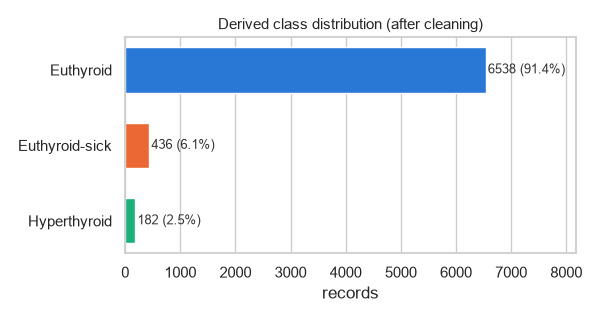

In [15]:
fig, ax = plt.subplots(figsize=(6, 3.2))
bars = ax.barh(CLASS_ORDER[::-1], class_distribution.set_index("derived_label").loc[CLASS_ORDER[::-1], "n"],
               color=[CLASS_COLORS[c] for c in CLASS_ORDER[::-1]], height=0.6)
for bar, (_, row) in zip(bars, class_distribution.set_index("derived_label").loc[CLASS_ORDER[::-1]].iterrows()):
    ax.text(bar.get_width() + 40, bar.get_y() + bar.get_height() / 2, f"{row['n']} ({row['pct']:.1f}%)",
            va="center", fontsize=9, color="#333")
ax.set_xlabel("records")
ax.set_xlim(0, class_distribution["n"].max() * 1.25)
ax.set_title("Derived class distribution (after cleaning)", fontsize=11)
ax.grid(axis="y", visible=False)
fig.tight_layout()
fig.savefig(ARTIFACTS / "class_distribution.png", dpi=FIG_DPI)
plt.close(fig)
display(Image(filename=str(ARTIFACTS / "class_distribution.png")))

In [16]:
def median_iqr(s):
    q = s.quantile([0.25, 0.5, 0.75])
    return f"{q[0.5]:.2f} [{q[0.25]:.2f}-{q[0.75]:.2f}]"

profile = data.groupby("derived_label", observed=True)[["age"] + HORMONES].agg(median_iqr).T
print("Median [IQR] by derived class:")
print(profile.to_string())

missing_by_class = (data.groupby("derived_label", observed=True)[HORMONES + ["TBG", "sex", "age"]]
                        .agg(lambda s: round(100 * s.isna().mean(), 1)))
print("\n% missing by derived class (missingness reflects which tests were ordered):")
print(missing_by_class.to_string())

Median [IQR] by derived class:

derived_label              Euthyroid         Euthyroid-sick            Hyperthyroid
age              54.00 [37.00-67.00]    70.00 [55.00-77.00]     53.00 [34.00-62.00]
TSH                 1.30 [0.52-2.20]       1.30 [0.42-2.50]        0.05 [0.02-0.15]
T3                  2.00 [1.60-2.30]       0.90 [0.70-1.00]        4.10 [3.40-5.30]
TT4            104.00 [90.00-120.00]   88.00 [72.00-103.00]  185.50 [152.25-229.00]
T4U                 0.96 [0.86-1.05]       0.83 [0.74-0.92]        0.92 [0.82-1.02]
FTI            109.00 [96.00-125.00]  107.00 [91.00-125.00]  202.00 [171.00-256.00]

% missing by derived class (missingness reflects which tests were ordered):
                 TSH    T3  TT4  T4U  FTI   TBG  sex  age
derived_label                                            
Euthyroid        7.0  27.2  1.7  6.0  5.9  99.5  3.2  0.1
Euthyroid-sick   0.7   2.3  0.5  3.2  3.2  99.8  2.5  0.0
Hyperthyroid    17.6  19.8  0.0  3.3  3.3  98.4  8.2  0.0


In [17]:
# Candidate proxy columns: share of 't' (=1) per class, and referral source distribution
proxy_cols = ["sick", "on_thyroxine", "query_on_thyroxine", "on_antithyroid_medication", "I131_treatment",
              "thyroid_surgery", "query_hypothyroid", "query_hyperthyroid"]
proxy_rates = (100 * data.groupby("derived_label", observed=True)[proxy_cols].mean()).round(1)
print("% of records with flag = t:")
print(proxy_rates.to_string())
ref = (100 * pd.crosstab(data["derived_label"], data["referral_source"], normalize="index")).round(1)
print("\nReferral source, % within class:")
print(ref.to_string())

% of records with flag = t:


                sick  on_thyroxine  query_on_thyroxine  on_antithyroid_medication  I131_treatment  thyroid_surgery  query_hypothyroid  query_hyperthyroid
derived_label                                                                                                                                            
Euthyroid        3.8          12.2                 1.7                        1.2             1.9              1.5                6.1                 6.2
Euthyroid-sick   8.9           3.4                 1.8                        0.5             0.0              0.0                7.6                 2.8
Hyperthyroid     2.2           2.2                 1.1                        3.8             2.7              0.0                3.3                40.7

Referral source, % within class:
referral_source  STMW  SVHC  SVHD   SVI  WEST  other
derived_label                                       
Euthyroid         1.9  12.8   0.8  25.6   0.0   58.9
Euthyroid-sick    0.0   5.3   0.9  8

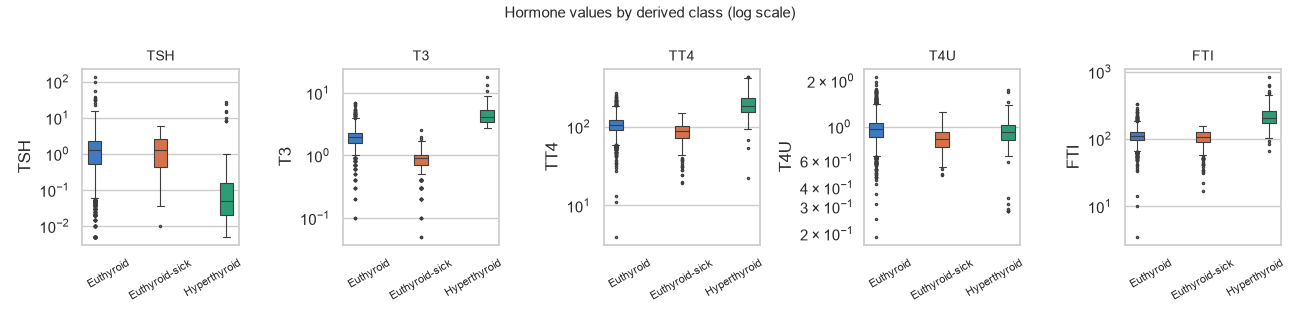

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(13, 3.2))
for ax, col in zip(axes, HORMONES):
    sns.boxplot(data=data, x="derived_label", y=col, hue="derived_label", order=CLASS_ORDER,
                palette=CLASS_COLORS, ax=ax, fliersize=1.5, linewidth=0.8, legend=False, log_scale=True)
    ax.set_xlabel("")
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
fig.suptitle("Hormone values by derived class (log scale)", fontsize=11)
fig.tight_layout()
fig.savefig(ARTIFACTS / "hormones_by_class.png", dpi=FIG_DPI)
plt.close(fig)
display(Image(filename=str(ARTIFACTS / "hormones_by_class.png")))

### 6.1 Does the derived labelling introduce ambiguity?
Three checks: (a) overlap of Euthyroid-sick with Euthyroid in hormone space, (b) nearest-neighbour label agreement, and (c) where the excluded mixed codes that contain `A-D` or `K` sit relative to the retained classes. Identical feature vectors with conflicting labels are checked in Section 8 (after the model features are fixed).

In [19]:
eu = data[data["derived_label"] == "Euthyroid"]
rows = []
for col in HORMONES:
    lo, hi = eu[col].quantile([0.05, 0.95])
    for cls in ["Euthyroid-sick", "Hyperthyroid"]:
        v = data.loc[data["derived_label"] == cls, col].dropna()
        rows.append({"hormone": col, "class": cls, "euthyroid_5-95%_range": f"{lo:.2f}-{hi:.2f}",
                     "pct_of_class_inside_range": round(100 * v.between(lo, hi).mean(), 1)})
overlap = pd.DataFrame(rows).pivot(index="hormone", columns="class", values="pct_of_class_inside_range")
print("% of each class whose value lies inside the central 90% of Euthyroid values:")
print(overlap.to_string())

# k-NN label agreement among complete cases (log hormones + age, standardised); descriptive only
cc = data.dropna(subset=HORMONES + ["age"])
Z = np.column_stack([np.log1p(cc[HORMONES].to_numpy()), cc[["age"]].to_numpy()])
Z = (Z - Z.mean(0)) / Z.std(0)
K_NN = 10
_, nn_idx = NearestNeighbors(n_neighbors=K_NN + 1).fit(Z).kneighbors(Z)
labels_cc = cc["derived_label"].to_numpy()
neigh = labels_cc[nn_idx[:, 1:]]
knn_tab = pd.DataFrame({cls: [(neigh[labels_cc == own] == cls).mean().round(3) for own in CLASS_ORDER]
                        for cls in CLASS_ORDER}, index=CLASS_ORDER)
knn_tab.index.name = f"own class (n complete cases={len(cc)})"
print(f"\nShare of the {K_NN} nearest neighbours belonging to each class:")
print(knn_tab.to_string())
overlap.to_csv(ARTIFACTS / "hormone_overlap.csv")
knn_tab.to_csv(ARTIFACTS / "knn_label_agreement.csv")

% of each class whose value lies inside the central 90% of Euthyroid values:
class    Euthyroid-sick  Hyperthyroid
hormone                              
FTI                84.8          13.1
T3                  2.3           1.4
T4U                81.0          83.5
TSH                91.5          40.7
TT4                77.6          21.4

Share of the 10 nearest neighbours belonging to each class:
                                   Euthyroid  Euthyroid-sick  Hyperthyroid
own class (n complete cases=4826)                                         
Euthyroid                              0.966           0.027         0.007
Euthyroid-sick                         0.366           0.634         0.000
Hyperthyroid                           0.347           0.000         0.653


In [20]:
# Hormone profile of excluded mixed codes that involve hyperthyroid (A-D) or non-thyroidal illness (K)
def code_group(code):
    if code in ("A", "B", "C", "D"):
        return "A/B/C/D (retained: Hyperthyroid)"
    if code == "K":
        return "K (retained: Euthyroid-sick)"
    if code == "-":
        return "- (retained: Euthyroid)"
    return code

related = df[df["diagnosis"].str.contains(r"[ABCDK]") | (df["diagnosis"] == "-")].copy()
related["group"] = related["diagnosis"].map(code_group)
mixed_profile = (related.groupby("group")[["age"] + HORMONES].median().round(2)
                 .join(related.groupby("group").size().rename("n")))
mixed_profile = mixed_profile.sort_values("n", ascending=False)
mixed_profile.to_csv(ARTIFACTS / "mixed_code_profiles.csv")
print("Median values per source-code group (all records, before exclusion):")
print(mixed_profile.to_string())

Median values per source-code group (all records, before exclusion):
                                   age    TSH    T3    TT4   T4U    FTI     n
group                                                                        
- (retained: Euthyroid)           54.0   1.30  2.00  104.0  0.96  109.0  6771
K (retained: Euthyroid-sick)      70.0   1.30  0.90   88.0  0.83  107.0   436
A/B/C/D (retained: Hyperthyroid)  53.0   0.05  4.10  185.5  0.92  202.0   182
GK                                69.0  11.00  0.80   86.0  0.86  107.0    49
AK                                62.0   0.08  1.85  170.0  0.89  198.0    46
MK                                49.5  24.50  0.90   87.0  0.93   94.0    16
C|I                               30.0   0.71  3.30  143.0  1.48   98.0    12
KJ                                69.0   1.40  0.80   87.0  0.49  178.0    11
H|K                               50.5   3.35  0.95   49.0  0.89   53.0     8
FK                                62.5   7.60  0.55   38.5  0.86   49.5  

## 7 Feature engineering and feature-set design
Each source column is audited for whether it is (a) an identifier, (b) derived from the diagnosis or from treatment decisions, (c) a process proxy (who referred the patient, which tests were ordered), or (d) a patient attribute / laboratory value that would legitimately be available when a classifier like this is applied. The **main feature set** keeps only (d). Excluded groups are added back one at a time in the ablation (Section 11) to measure how much each contributes.

Transformations (all inside the scikit-learn `Pipeline`, fitted on training folds only):
* hormones: median imputation, `log1p` (TSH, T3, TT4 and FTI are strongly right-skewed), standardisation;
* age: median imputation, standardisation;
* binary flags (already 0/1) and sex: most-frequent imputation;
* referral source (ablation only): one-hot encoding; missing-value indicators (ablation only): `MissingIndicator`.

No outlier clipping is applied: extreme hormone values (e.g. suppressed TSH, FTI far above the reference range) are physiologically meaningful for hyperthyroidism, and the log transform limits their leverage for the linear and kernel models. The only value-level rule is the age > 120 -> NaN rule from Section 5.

In [21]:
CLINICAL_FLAGS = ["pregnant", "lithium", "goitre", "tumor", "hypopituitary", "psych"]
TREATMENT = ["on_thyroxine", "query_on_thyroxine", "on_antithyroid_medication", "I131_treatment", "thyroid_surgery"]
QUERY = ["query_hypothyroid", "query_hyperthyroid"]

feature_audit = pd.DataFrame(
    [("record_id", "identifier", "excluded", "record identifier; no predictive meaning, would enable memorisation")]
    + [("diagnosis", "source label", "excluded", "source diagnosis code from which the target is derived")]
    + [(c, "laboratory value", "MAIN", "thyroid hormone measurement") for c in HORMONES]
    + [("age", "demographic", "MAIN", "patient attribute (ages > 120 set to NaN)"),
       ("sex", "demographic", "MAIN", "patient attribute")]
    + [(c, "clinical history", "MAIN", "patient condition/medication not tied to the target codes") for c in CLINICAL_FLAGS]
    + [(c, "treatment history/decision", "ablation only",
        "records past thyroid treatment decisions; linked to excluded codes L-Q and alters hormone levels") for c in TREATMENT]
    + [("sick", "target proxy risk", "ablation only",
        "'sick' flag may encode the same judgement as code K (concurrent non-thyroidal illness)")]
    + [(c, "process proxy", "ablation only", "the referring clinician's question, i.e. a suspicion, not a measurement") for c in QUERY]
    + [("referral_source", "process proxy", "ablation only", "which clinic/route referred the sample; site, not physiology")]
    + [(c, "process proxy", "ablation only (as missing indicators)",
        "identical to missingness of the value; encodes which tests were ordered") for c in MEASURED_FLAGS]
    + [("TBG", "laboratory value", "ablation only", "missing in about 96% of retained records")],
    columns=["column", "group", "decision", "reason"])
feature_audit.to_csv(ARTIFACTS / "feature_audit.csv", index=False)
print(feature_audit.to_string(index=False))

                   column                      group                              decision                                                                                           reason
                record_id                 identifier                              excluded                              record identifier; no predictive meaning, would enable memorisation
                diagnosis               source label                              excluded                                           source diagnosis code from which the target is derived
                      TSH           laboratory value                                  MAIN                                                                      thyroid hormone measurement
                       T3           laboratory value                                  MAIN                                                                      thyroid hormone measurement
                      TT4           laboratory value        

In [22]:
MAIN = {"hormones": HORMONES, "age": ["age"], "binary": ["sex"] + CLINICAL_FLAGS, "categorical": [], "missing": []}

def extend(base, **extra):
    fs = {k: list(v) for k, v in base.items()}
    for k, v in extra.items():
        fs[k] = fs[k] + list(v)
    return fs

FEATURE_SETS = {
    "main": MAIN,
    "main + sick": extend(MAIN, binary=["sick"]),
    "main + treatment history": extend(MAIN, binary=TREATMENT),
    "main + clinician query flags": extend(MAIN, binary=QUERY),
    "main + referral source": extend(MAIN, categorical=["referral_source"]),
    "main + missingness indicators": extend(MAIN, missing=HORMONES),
    "main + TBG": extend(MAIN, hormones=["TBG"]),
    "full (all source attributes)": extend(MAIN, binary=["sick"] + TREATMENT + QUERY, categorical=["referral_source"],
                                           hormones=["TBG"], missing=HORMONES + ["TBG"]),
}

def feature_columns(fs):
    cols = fs["hormones"] + fs["age"] + fs["binary"] + fs["categorical"] + fs["missing"]
    return list(dict.fromkeys(cols))

def build_preprocessor(fs):
    transformers = [
        ("hormones", Pipeline([("impute", SimpleImputer(strategy="median")),
                               ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                               ("scale", StandardScaler())]), fs["hormones"]),
        ("age", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), fs["age"]),
        ("binary", SimpleImputer(strategy="most_frequent"), fs["binary"]),
    ]
    if fs["categorical"]:
        transformers.append(("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fs["categorical"]))
    if fs["missing"]:
        transformers.append(("missing", MissingIndicator(features="all"), fs["missing"]))
    return ColumnTransformer(transformers, remainder="drop", sparse_threshold=0.0)

MAIN_COLUMNS = feature_columns(MAIN)
CANDIDATE_COLUMNS = feature_columns(FEATURE_SETS["full (all source attributes)"])
print("Main feature set:", MAIN_COLUMNS)
print({name: len(feature_columns(fs)) for name, fs in FEATURE_SETS.items()})

Main feature set: ['TSH', 'T3', 'TT4', 'T4U', 'FTI', 'age', 'sex', 'pregnant', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych']
{'main': 13, 'main + sick': 14, 'main + treatment history': 18, 'main + clinician query flags': 15, 'main + referral source': 14, 'main + missingness indicators': 13, 'main + TBG': 14, 'full (all source attributes)': 23}


## 8 Train / validation / test split
* **Grouping.** Records with an identical main-feature vector form one group, so identical model inputs can never fall on both sides of any split (exact duplicates were already removed in Section 5; this additionally covers records that differ only in excluded columns).
* **Test hold-out.** One fold of a stratified, grouped 5-fold split (`StratifiedGroupKFold`, `shuffle=True`, `random_state=SEED`), about 20 %. It is not used until Section 13.
* **Validation = CV folds.** Hyper-parameter tuning uses stratified, grouped 5-fold CV on the training portion (seed `SEED`); model comparison and the ablation use 3 x 5-fold repeated stratified, grouped CV with seeds `CV_REPEAT_SEEDS`.
* **Imbalance.** No oversampling or rebalancing anywhere. Imbalance is handled with class weights (`class_weight='balanced'` or `'balanced_subsample'`), because they keep every real record exactly once, need no synthetic data, and are applied inside each training fit automatically.

In [23]:
X_all = data[CANDIDATE_COLUMNS].copy()
y_all = data["derived_label"].astype(str).to_numpy()
groups_all = data.groupby(MAIN_COLUMNS, dropna=False, sort=False).ngroup().to_numpy()

group_label_counts = pd.Series(y_all).groupby(groups_all).nunique()
group_sizes = pd.Series(groups_all).value_counts()
print(f"Records: {len(data)} | distinct main-feature vectors (groups): {group_sizes.size} | "
      f"records sharing a vector with another record: {int(group_sizes[group_sizes > 1].sum())}")
print("Groups whose identical feature vectors carry different derived labels:", int((group_label_counts > 1).sum()))

holdout = StratifiedGroupKFold(n_splits=HOLDOUT_FOLDS, shuffle=True, random_state=SEED)
train_idx, test_idx = next(holdout.split(X_all, y_all, groups_all))
assert not set(groups_all[train_idx]) & set(groups_all[test_idx])

X_train, X_test = X_all.iloc[train_idx].reset_index(drop=True), X_all.iloc[test_idx].reset_index(drop=True)
y_train, y_test = y_all[train_idx], y_all[test_idx]
g_train = groups_all[train_idx]

split_summary = pd.DataFrame({
    "train": pd.Series(y_train).value_counts().reindex(CLASS_ORDER),
    "test": pd.Series(y_test).value_counts().reindex(CLASS_ORDER)})
split_summary.loc["total"] = split_summary.sum()
split_summary["test_share_%"] = (100 * split_summary["test"] / (split_summary["train"] + split_summary["test"])).round(1)
split_summary.to_csv(ARTIFACTS / "split_summary.csv")
print(split_summary.to_string())

def grouped_splits(seed):
    cv = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=seed)
    return list(cv.split(X_train, y_train, g_train))

TUNE_SPLITS = grouped_splits(SEED)
EVAL_SPLITS = [split for s in CV_REPEAT_SEEDS for split in grouped_splits(s)]
print(f"Tuning CV: {len(TUNE_SPLITS)} folds | evaluation CV: {len(EVAL_SPLITS)} folds "
      f"(validation fold size about {len(X_train) // CV_FOLDS})")

Records: 7156 | distinct main-feature vectors (groups): 7154 | records sharing a vector with another record: 4
Groups whose identical feature vectors carry different derived labels: 0


                train  test  test_share_%
Euthyroid        5230  1308          20.0
Euthyroid-sick    349    87          20.0
Hyperthyroid      146    36          19.8
total            5725  1431          20.0


Tuning CV: 5 folds | evaluation CV: 15 folds (validation fold size about 1145)


## 9 Baselines
Two dummy classifiers set the floor: always predicting the majority class, and predicting at random with the training class frequencies.

In [24]:
def recall_of(label):
    return make_scorer(recall_score, labels=[label], average="macro", zero_division=0)

SCORING = {"macro_f1": "f1_macro", "weighted_f1": "f1_weighted", "balanced_accuracy": "balanced_accuracy",
           "accuracy": "accuracy", **{f"recall_{c}": recall_of(c) for c in CLASS_ORDER}}

def evaluate_cv(pipeline, splits=None):
    res = cross_validate(pipeline, X_train, y_train, cv=splits or EVAL_SPLITS, scoring=SCORING, n_jobs=N_JOBS)
    return {k[5:]: res[k] for k in res if k.startswith("test_")}

def summarise(name, scores, params=""):
    row = {"model": name, "params": params}
    for k, v in scores.items():
        row[f"{k}_mean"] = v.mean()
        row[f"{k}_std"] = v.std(ddof=1)
    return row

cv_rows = []
for name, strategy in [("Dummy (majority class)", "most_frequent"), ("Dummy (stratified random)", "stratified")]:
    pipe = Pipeline([("prep", build_preprocessor(MAIN)), ("clf", DummyClassifier(strategy=strategy, random_state=SEED))])
    cv_rows.append(summarise(name, evaluate_cv(pipe)))
pd.DataFrame(cv_rows)[["model", "macro_f1_mean", "macro_f1_std", "balanced_accuracy_mean", "accuracy_mean"]]

,model,macro_f1_mean,macro_f1_std,balanced_accuracy_mean,accuracy_mean
0,Dummy (majority class),0.3183,5.4904e-05,0.3333,0.9135
1,Dummy (stratified random),0.3363,1.9685e-02,0.3373,0.8371


## 10 Model training
Four model families, each with class weighting and a small hyper-parameter grid tuned by macro F1 on the tuning CV folds (training data only). The best configuration of each is then re-scored on the 15 repeated evaluation folds. LightGBM is tried as an optional fifth model and kept only if it adds measurable value (Section 11).

The SVM is tuned without probability calibration (class predictions come from its decision function either way); the final SVM, if selected, is refit with `probability=True` only to obtain scores for ROC-AUC.

In [25]:
MODELS = {
    "Logistic Regression": (LogisticRegression(class_weight="balanced", max_iter=5000, random_state=SEED),
                            {"clf__C": [0.01, 0.1, 1.0, 10.0]}),
    "Random Forest": (RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", n_jobs=1,
                                             random_state=SEED),
                      {"clf__max_depth": [None, 12], "clf__min_samples_leaf": [1, 3]}),
    "RBF SVM": (SVC(kernel="rbf", class_weight="balanced", random_state=SEED),
                {"clf__C": [1.0, 10.0, 100.0, 1000.0], "clf__gamma": ["scale", 0.03]}),
    "HistGradientBoosting": (HistGradientBoostingClassifier(class_weight="balanced", max_iter=200, random_state=SEED),
                             {"clf__learning_rate": [0.05, 0.1], "clf__max_leaf_nodes": [15, 31]}),
    "LightGBM (optional)": (LGBMClassifier(n_estimators=300, class_weight="balanced", n_jobs=1, verbose=-1,
                                           random_state=SEED),
                            {"clf__learning_rate": [0.03, 0.1], "clf__num_leaves": [15, 31]}),
}

best_params, cv_scores, train_times = {}, {}, {}
for name, (estimator, grid) in MODELS.items():
    t0 = time.perf_counter()
    pipe = Pipeline([("prep", build_preprocessor(MAIN)), ("clf", clone(estimator))])
    search = GridSearchCV(pipe, grid, cv=TUNE_SPLITS, scoring="f1_macro", n_jobs=N_JOBS, refit=False)
    search.fit(X_train, y_train)
    best_params[name] = search.best_params_
    cv_scores[name] = evaluate_cv(clone(pipe).set_params(**search.best_params_))
    train_times[name] = time.perf_counter() - t0
    cv_rows.append(summarise(name, cv_scores[name], json.dumps({k[5:]: v for k, v in search.best_params_.items()})))
    print(f"{name:22s} tuning-CV macro F1 {search.best_score_:.4f} | repeated-CV macro F1 "
          f"{cv_scores[name]['macro_f1'].mean():.4f} +/- {cv_scores[name]['macro_f1'].std(ddof=1):.4f} | "
          f"{train_times[name]:.0f}s | {search.best_params_}")

Logistic Regression    tuning-CV macro F1 0.7288 | repeated-CV macro F1 0.7258 +/- 0.0122 | 0s | {'clf__C': 1.0}


Random Forest          tuning-CV macro F1 0.8941 | repeated-CV macro F1 0.8863 +/- 0.0163 | 2s | {'clf__max_depth': 12, 'clf__min_samples_leaf': 3}


RBF SVM                tuning-CV macro F1 0.8371 | repeated-CV macro F1 0.8190 +/- 0.0195 | 1s | {'clf__C': 100.0, 'clf__gamma': 'scale'}


HistGradientBoosting   tuning-CV macro F1 0.8952 | repeated-CV macro F1 0.8760 +/- 0.0201 | 2s | {'clf__learning_rate': 0.1, 'clf__max_leaf_nodes': 31}


LightGBM (optional)    tuning-CV macro F1 0.8907 | repeated-CV macro F1 0.8843 +/- 0.0145 | 1s | {'clf__learning_rate': 0.03, 'clf__num_leaves': 31}


## 11 Model comparison
Mean +/- standard deviation over the 15 evaluation folds (3 repeats x 5 folds) on the training portion. The test set is not involved.

In [26]:
cv_table = pd.DataFrame(cv_rows)
cv_table.to_csv(ARTIFACTS / "cv_model_comparison.csv", index=False)
show = cv_table[["model"]].copy()
for m in ["macro_f1", "balanced_accuracy", "weighted_f1", "accuracy",
          "recall_Hyperthyroid", "recall_Euthyroid-sick", "recall_Euthyroid"]:
    show[m] = cv_table[f"{m}_mean"].map("{:.3f}".format) + " +/- " + cv_table[f"{m}_std"].map("{:.3f}".format)
print(show.to_string(index=False))

                    model        macro_f1 balanced_accuracy     weighted_f1        accuracy recall_Hyperthyroid recall_Euthyroid-sick recall_Euthyroid
   Dummy (majority class) 0.318 +/- 0.000   0.333 +/- 0.000 0.872 +/- 0.000 0.914 +/- 0.000     0.000 +/- 0.000       0.000 +/- 0.000  1.000 +/- 0.000
Dummy (stratified random) 0.336 +/- 0.020   0.337 +/- 0.021 0.838 +/- 0.006 0.837 +/- 0.006     0.048 +/- 0.044       0.053 +/- 0.030  0.912 +/- 0.004
      Logistic Regression 0.726 +/- 0.012   0.936 +/- 0.019 0.919 +/- 0.006 0.905 +/- 0.008     0.938 +/- 0.054       0.969 +/- 0.025  0.900 +/- 0.009
            Random Forest 0.886 +/- 0.016   0.932 +/- 0.022 0.973 +/- 0.003 0.972 +/- 0.003     0.842 +/- 0.068       0.979 +/- 0.022  0.975 +/- 0.003
                  RBF SVM 0.819 +/- 0.019   0.834 +/- 0.022 0.959 +/- 0.004 0.958 +/- 0.004     0.705 +/- 0.083       0.823 +/- 0.055  0.974 +/- 0.004
     HistGradientBoosting 0.876 +/- 0.020   0.892 +/- 0.033 0.971 +/- 0.004 0.971 +/- 0.004   

In [27]:
CORE = ["Logistic Regression", "Random Forest", "RBF SVM", "HistGradientBoosting"]
core_means = {m: cv_scores[m]["macro_f1"].mean() for m in CORE}
best_core = max(core_means, key=core_means.get)
lgbm_gain = cv_scores["LightGBM (optional)"]["macro_f1"].mean() - core_means[best_core]
lgbm_threshold = cv_scores[best_core]["macro_f1"].std(ddof=1)
keep_lgbm = lgbm_gain > lgbm_threshold
print(f"Best core model by CV macro F1: {best_core} ({core_means[best_core]:.4f})")
print(f"LightGBM gain over it: {lgbm_gain:+.4f} (rule: keep only if gain > 1 CV std = {lgbm_threshold:.4f}) "
      f"-> {'kept' if keep_lgbm else 'dropped'}")

candidates = CORE + (["LightGBM (optional)"] if keep_lgbm else [])
FINAL_MODEL_NAME = max(candidates, key=lambda m: cv_scores[m]["macro_f1"].mean())
FINAL_PARAMS = best_params[FINAL_MODEL_NAME]
print(f"Selected final model (highest repeated-CV macro F1): {FINAL_MODEL_NAME} with {FINAL_PARAMS}")

Best core model by CV macro F1: Random Forest (0.8863)
LightGBM gain over it: -0.0020 (rule: keep only if gain > 1 CV std = 0.0163) -> dropped
Selected final model (highest repeated-CV macro F1): Random Forest with {'clf__max_depth': 12, 'clf__min_samples_leaf': 3}


### 11.1 Feature-set ablation (training CV only)
The selected model type, with its tuned hyper-parameters, is re-scored on the same 15 evaluation folds with each excluded column group added back to the main set. A large gain from a proxy group would mean the model can exploit process information that is not physiology.

In [28]:
def final_estimator(name=FINAL_MODEL_NAME, params=FINAL_PARAMS, probability=False):
    est = clone(MODELS[name][0]).set_params(**{k[5:]: v for k, v in params.items()})
    if isinstance(est, SVC):
        est.set_params(probability=probability)
    return est

ablation_rows = []
for fs_name, fs in FEATURE_SETS.items():
    pipe = Pipeline([("prep", build_preprocessor(fs)), ("clf", final_estimator())])
    sc = evaluate_cv(pipe)
    ablation_rows.append({"feature_set": fs_name, "n_input_columns": len(feature_columns(fs)),
                          **{f"{k}_mean": v.mean() for k, v in sc.items() if k in
                             ("macro_f1", "balanced_accuracy", "recall_Hyperthyroid", "recall_Euthyroid-sick")},
                          "macro_f1_std": sc["macro_f1"].std(ddof=1)})
ablation = pd.DataFrame(ablation_rows)
ablation["delta_macro_f1_vs_main"] = ablation["macro_f1_mean"] - ablation.loc[0, "macro_f1_mean"]
ablation.to_csv(ARTIFACTS / "ablation_cv.csv", index=False)
print(f"Model: {FINAL_MODEL_NAME}")
print(ablation.round(4).to_string(index=False))

Model: Random Forest
                  feature_set  n_input_columns  macro_f1_mean  balanced_accuracy_mean  recall_Euthyroid-sick_mean  recall_Hyperthyroid_mean  macro_f1_std  delta_macro_f1_vs_main
                         main               13         0.8863                  0.9321                      0.9790                    0.8423        0.0163                  0.0000
                  main + sick               14         0.8875                  0.9347                      0.9781                    0.8513        0.0146                  0.0012
     main + treatment history               18         0.8892                  0.9329                      0.9790                    0.8444        0.0175                  0.0029
 main + clinician query flags               15         0.8878                  0.9317                      0.9781                    0.8422        0.0148                  0.0015
       main + referral source               14         0.9155                  0.9355    

### 11.2 Single-feature proxy probe
A shallow, class-weighted decision tree (depth 3) trained on one column at a time, scored with macro F1 on the first 5 evaluation folds. A single column that nearly solves the task on its own would be a red flag for a target proxy.

In [29]:
probe_rows = []
probe_splits = EVAL_SPLITS[:CV_FOLDS]
for col in MAIN_COLUMNS + ["sick"] + TREATMENT + QUERY + ["referral_source", "TBG"]:
    if col == "referral_source":
        prep = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    else:
        prep = SimpleImputer(strategy="median", add_indicator=False, keep_empty_features=True)
    pipe = Pipeline([("prep", ColumnTransformer([("x", prep, [col])], sparse_threshold=0.0)),
                     ("clf", DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=SEED))])
    res = cross_validate(pipe, X_train, y_train, cv=probe_splits, scoring="f1_macro", n_jobs=N_JOBS)
    probe_rows.append({"column": col, "in_main_set": col in MAIN_COLUMNS,
                       "macro_f1_mean": res["test_score"].mean(), "macro_f1_std": res["test_score"].std(ddof=1)})
probe = pd.DataFrame(probe_rows).sort_values("macro_f1_mean", ascending=False)
probe.to_csv(ARTIFACTS / "single_feature_probe.csv", index=False)
print(probe.round(4).to_string(index=False))

                   column  in_main_set  macro_f1_mean  macro_f1_std
                       T3         True         0.7745        0.0222
                      FTI         True         0.5079        0.0144
                      TT4         True         0.3204        0.0553
                      T4U         True         0.3187        0.0115
                      TSH         True         0.2416        0.1229
                      age         True         0.2155        0.0347
          referral_source        False         0.1964        0.0078
       query_hyperthyroid        False         0.1257        0.0137
             on_thyroxine        False         0.0935        0.0073
                    tumor         True         0.0676        0.0241
                      sex         True         0.0616        0.0066
on_antithyroid_medication        False         0.0600        0.0085
                    psych         True         0.0530        0.0039
           I131_treatment        False         0

## 12 Final model
The selected configuration is refit once on the full training portion (main feature set). Nothing about it is changed after this point.

In [30]:
final_pipeline = Pipeline([("prep", build_preprocessor(MAIN)), ("clf", final_estimator(probability=True))])
t0 = time.perf_counter()
final_pipeline.fit(X_train[MAIN_COLUMNS], y_train)
print(f"{FINAL_MODEL_NAME} fitted on {len(X_train)} training records in {time.perf_counter() - t0:.1f}s")
print("Classes:", list(final_pipeline.classes_))
final_pipeline

Random Forest fitted on 5725 training records in 0.9s
Classes: ['Euthyroid', 'Euthyroid-sick', 'Hyperthyroid']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Euthyroid','Euthyroid-sick','Hyperthyroid']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['TSH','T3','TT4',...,'tumor','hypopituitary','psych']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('hormones', ...), ('age', ...), ...]"
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. W

## 13 Evaluation on the held-out test set
This is the only place the test set is used. Bootstrap 95 % confidence intervals (percentile method) resample test records with replacement.

In [31]:
X_test_main = X_test[MAIN_COLUMNS]
y_pred = final_pipeline.predict(X_test_main)
proba = final_pipeline.predict_proba(X_test_main)
class_idx = {c: list(final_pipeline.classes_).index(c) for c in CLASS_ORDER}
proba = proba[:, [class_idx[c] for c in CLASS_ORDER]]          # columns in CLASS_ORDER

def headline(yt, yp, pr):
    out = {"accuracy": accuracy_score(yt, yp),
           "macro_f1": f1_score(yt, yp, average="macro", labels=CLASS_ORDER, zero_division=0),
           "weighted_f1": f1_score(yt, yp, average="weighted", labels=CLASS_ORDER, zero_division=0),
           "balanced_accuracy": balanced_accuracy_score(yt, yp)}
    for c in MINORITY_CLASSES:
        out[f"recall_{c}"] = recall_score(yt, yp, labels=[c], average="macro", zero_division=0)
    out["roc_auc_ovr_macro"] = roc_auc_score(yt, pr, multi_class="ovr", average="macro", labels=CLASS_ORDER)
    return out

test_point = headline(y_test, y_pred, proba)
rng = np.random.default_rng(SEED)
boot = []
n_test = len(y_test)
for _ in range(N_BOOTSTRAP):
    idx = rng.integers(0, n_test, n_test)
    if len(set(y_test[idx])) < len(CLASS_ORDER):
        continue
    boot.append(headline(y_test[idx], y_pred[idx], proba[idx]))
boot = pd.DataFrame(boot)
test_metrics = pd.DataFrame({"value": test_point,
                             "ci95_low": boot.quantile(0.025), "ci95_high": boot.quantile(0.975)})
test_metrics.index.name = "metric"
test_metrics.to_csv(ARTIFACTS / "test_metrics.csv")
print(f"Test set: {n_test} records | bootstrap resamples used: {len(boot)}")
print(test_metrics.round(4).to_string())

dummy = DummyClassifier(strategy="most_frequent").fit(X_train[MAIN_COLUMNS], y_train)
yd = dummy.predict(X_test_main)
print(f"\nReference, majority-class dummy on the same test set: accuracy {accuracy_score(y_test, yd):.4f}, "
      f"macro F1 {f1_score(y_test, yd, average='macro', labels=CLASS_ORDER, zero_division=0):.4f}, "
      f"balanced accuracy {balanced_accuracy_score(y_test, yd):.4f}")


Test set: 1431 records | bootstrap resamples used: 2000
                        value  ci95_low  ci95_high
metric                                            
accuracy               0.9790    0.9713     0.9860
macro_f1               0.9082    0.8695     0.9402
weighted_f1            0.9798    0.9726     0.9864
balanced_accuracy      0.9563    0.9192     0.9862
recall_Hyperthyroid    0.8889    0.7777     0.9756
recall_Euthyroid-sick  1.0000    1.0000     1.0000
roc_auc_ovr_macro      0.9968    0.9950     0.9984

Reference, majority-class dummy on the same test set: accuracy 0.9140, macro F1 0.3184, balanced accuracy 0.3333


In [32]:
p, r, f, s = precision_recall_fscore_support(y_test, y_pred, labels=CLASS_ORDER, zero_division=0)
auc_per_class = [roc_auc_score(y_test == c, proba[:, i]) for i, c in enumerate(CLASS_ORDER)]
ap_per_class = [average_precision_score(y_test == c, proba[:, i]) for i, c in enumerate(CLASS_ORDER)]
# Exact (Clopper-Pearson) 95% interval for each class recall: informative even when recall is 1.0,
# where the bootstrap percentile interval collapses to a single point.
recall_ci = [scipy.stats.binomtest(int(round(r_i * s_i)), int(s_i)).proportion_ci(confidence_level=0.95, method="exact")
             for r_i, s_i in zip(r, s)]
per_class = pd.DataFrame({"precision": p, "recall": r, "recall_ci95_exact_low": [ci.low for ci in recall_ci],
                          "recall_ci95_exact_high": [ci.high for ci in recall_ci], "f1": f, "support": s,
                          "roc_auc_ovr": auc_per_class, "average_precision": ap_per_class}, index=CLASS_ORDER)
per_class.index.name = "derived_class"
per_class.to_csv(ARTIFACTS / "test_per_class.csv")
print(per_class.round(4).to_string())

cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
cm_raw = pd.DataFrame(cm, index=[f"true {c}" for c in CLASS_ORDER], columns=[f"pred {c}" for c in CLASS_ORDER])
cm_norm = (cm_raw.div(cm_raw.sum(axis=1), axis=0)).round(3)
cm_raw.to_csv(ARTIFACTS / "confusion_matrix_raw.csv")
cm_norm.to_csv(ARTIFACTS / "confusion_matrix_normalized.csv")
print("\nConfusion matrix (counts):")
print(cm_raw.to_string())
print("\nConfusion matrix (row-normalised = recall per true class):")
print(cm_norm.to_string())


                precision  recall  recall_ci95_exact_low  recall_ci95_exact_high      f1  support  roc_auc_ovr  average_precision
derived_class                                                                                                                    
Euthyroid          0.9969  0.9801                 0.9710                  0.9870  0.9884     1308       0.9953             0.9996
Euthyroid-sick     0.8447  1.0000                 0.9585                  1.0000  0.9158       87       0.9975             0.9574
Hyperthyroid       0.7619  0.8889                 0.7394                  0.9689  0.8205       36       0.9976             0.8855

Confusion matrix (counts):
                     pred Euthyroid  pred Euthyroid-sick  pred Hyperthyroid
true Euthyroid                 1282                   16                 10
true Euthyroid-sick               0                   87                  0
true Hyperthyroid                 4                    0                 32

Confusion matrix 

## 14 Visualization

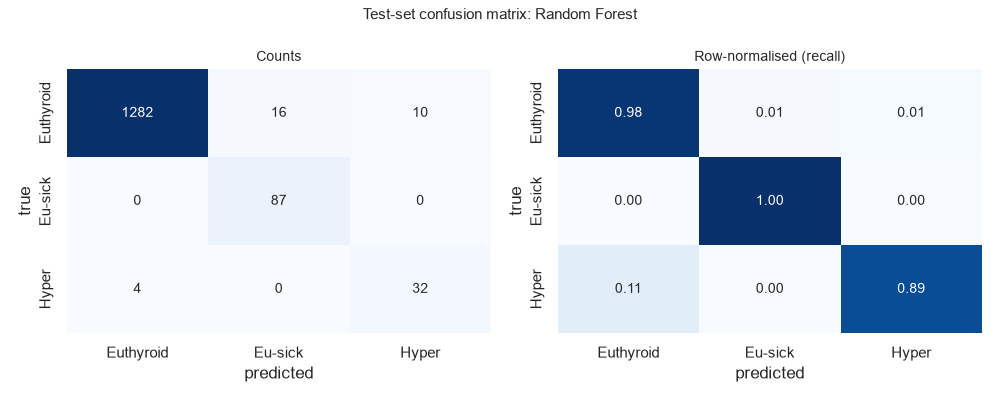

In [33]:
def save_show(fig, name):
    fig.savefig(ARTIFACTS / name, dpi=FIG_DPI)
    plt.close(fig)
    display(Image(filename=str(ARTIFACTS / name)))

short = ["Euthyroid", "Eu-sick", "Hyper"]
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_raw.values, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=short, yticklabels=short, annot_kws={"size": 10})
sns.heatmap(cm_norm.values, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=False, ax=axes[1],
            xticklabels=short, yticklabels=short, annot_kws={"size": 10})
for ax, title in zip(axes, ["Counts", "Row-normalised (recall)"]):
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title, fontsize=10)
fig.suptitle(f"Test-set confusion matrix: {FINAL_MODEL_NAME}", fontsize=11)
fig.tight_layout()
save_show(fig, "confusion_matrix.png")


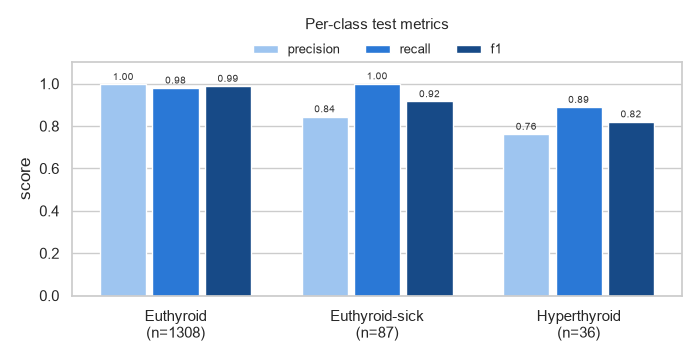

In [34]:
fig, ax = plt.subplots(figsize=(7, 3.6))
metric_cols = ["precision", "recall", "f1"]
width = 0.26
xs = np.arange(len(CLASS_ORDER))
shades = {"precision": "#9ec5f0", "recall": "#2a78d6", "f1": "#174a87"}
for i, m in enumerate(metric_cols):
    bars = ax.bar(xs + (i - 1) * width, per_class[m], width=width - 0.03, color=shades[m], label=m)
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01, f"{b.get_height():.2f}",
                ha="center", va="bottom", fontsize=7.5, color="#333")
ax.set_xticks(xs, [f"{c}\n(n={int(per_class.loc[c, 'support'])})" for c in CLASS_ORDER])
ax.set_ylim(0, 1.1)
ax.set_ylabel("score")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.13), frameon=False, fontsize=9)
ax.set_title("Per-class test metrics", fontsize=11, pad=24)
ax.grid(axis="x", visible=False)
fig.tight_layout()
save_show(fig, "per_class_metrics.png")


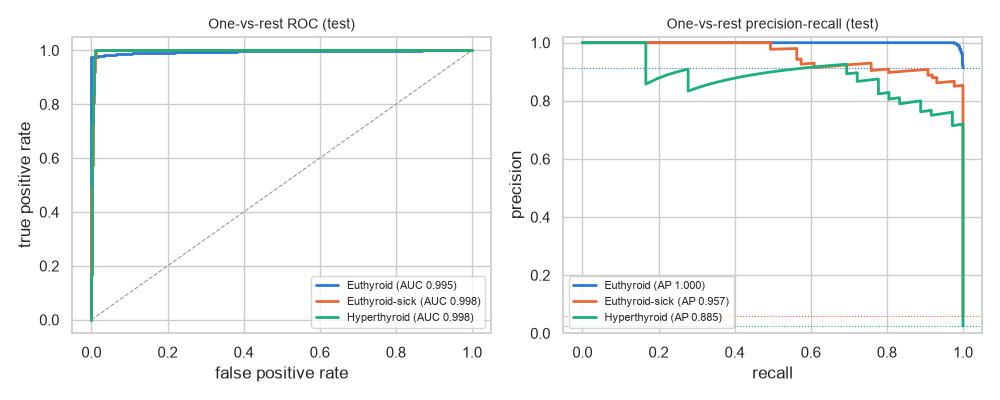

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, c in enumerate(CLASS_ORDER):
    fpr, tpr, _ = roc_curve(y_test == c, proba[:, i])
    axes[0].plot(fpr, tpr, color=CLASS_COLORS[c], lw=2, label=f"{c} (AUC {auc_per_class[i]:.3f})")
    prec, rec, _ = precision_recall_curve(y_test == c, proba[:, i])
    axes[1].plot(rec, prec, color=CLASS_COLORS[c], lw=2, label=f"{c} (AP {ap_per_class[i]:.3f})")
    axes[1].axhline((y_test == c).mean(), color=CLASS_COLORS[c], lw=0.8, ls=":")
axes[0].plot([0, 1], [0, 1], color="#999", lw=0.8, ls="--")
axes[0].set(xlabel="false positive rate", ylabel="true positive rate", title="One-vs-rest ROC (test)")
axes[1].set(xlabel="recall", ylabel="precision", title="One-vs-rest precision-recall (test)", ylim=(0, 1.02))
for ax in axes:
    ax.legend(fontsize=8, loc="lower right" if ax is axes[0] else "lower left")
    ax.title.set_fontsize(10)
fig.tight_layout()
save_show(fig, "roc_pr_ovr.png")


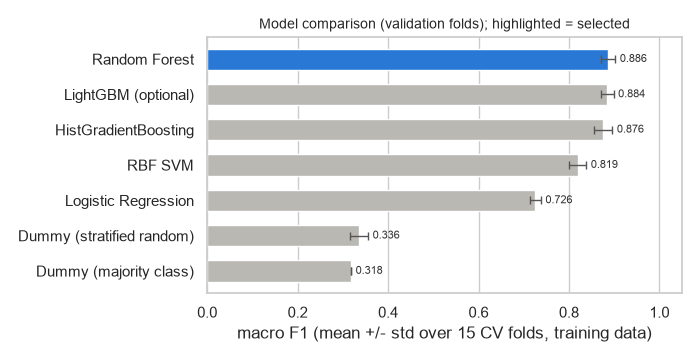

In [36]:
order = cv_table.sort_values("macro_f1_mean")
fig, ax = plt.subplots(figsize=(7, 3.6))
colors = ["#2a78d6" if m == FINAL_MODEL_NAME else "#b9b8b2" for m in order["model"]]
ax.barh(order["model"], order["macro_f1_mean"], xerr=order["macro_f1_std"], color=colors, height=0.6,
        error_kw={"elinewidth": 1, "capsize": 3, "ecolor": "#555"})
for yv, (mean, std) in enumerate(zip(order["macro_f1_mean"], order["macro_f1_std"])):
    ax.text(mean + std + 0.01, yv, f"{mean:.3f}", va="center", fontsize=8, color="#333")
ax.set_xlim(0, 1.05)
ax.set_xlabel("macro F1 (mean +/- std over 15 CV folds, training data)")
ax.set_title("Model comparison (validation folds); highlighted = selected", fontsize=10)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_show(fig, "cv_model_comparison.png")


## 15 Explainability
### 15.1 Permutation importance (held-out test set, scoring = macro F1)
Each input column is shuffled 20 times; the drop in macro F1 measures how much the fitted model relies on it. Correlated columns (TT4, FTI, T4U) can share importance, so a low value does not mean a column is uninformative.

      feature  importance_mean  importance_std
           T3           0.3100          0.0139
          FTI           0.0899          0.0088
          TT4           0.0638          0.0141
        tumor           0.0004          0.0011
          T4U           0.0002          0.0020
hypopituitary           0.0000          0.0000
      lithium           0.0000          0.0000
     pregnant           0.0000          0.0000
       goitre          -0.0002          0.0008
        psych          -0.0002          0.0008
          sex          -0.0048          0.0030
          age          -0.0049          0.0039
          TSH          -0.0050          0.0065


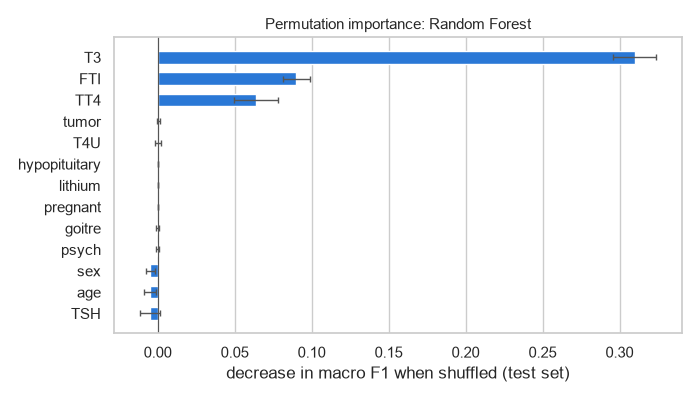

In [37]:
pi = permutation_importance(final_pipeline, X_test_main, y_test, scoring="f1_macro",
                            n_repeats=N_PERM_REPEATS, random_state=SEED, n_jobs=N_JOBS)
perm = (pd.DataFrame({"feature": MAIN_COLUMNS, "importance_mean": pi.importances_mean,
                      "importance_std": pi.importances_std})
          .sort_values("importance_mean", ascending=False).reset_index(drop=True))
perm.to_csv(ARTIFACTS / "permutation_importance.csv", index=False)
print(perm.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
p_sorted = perm.iloc[::-1]
ax.barh(p_sorted["feature"], p_sorted["importance_mean"], xerr=p_sorted["importance_std"], color="#2a78d6",
        height=0.6, error_kw={"elinewidth": 1, "capsize": 2, "ecolor": "#555"})
ax.axvline(0, color="#555", lw=0.8)
ax.set_xlabel("decrease in macro F1 when shuffled (test set)")
ax.set_title(f"Permutation importance: {FINAL_MODEL_NAME}", fontsize=11)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save_show(fig, "permutation_importance.png")


### 15.2 Where do the excluded mixed codes land?
Records with mixed or ambiguous codes involving `A-D` or `K` were never used for training or testing. Scoring them with the final model shows how the derived classes relate to these borderline cases (records without any hormone value are skipped).

In [38]:
mixed = df[df["diagnosis"].str.contains(r"[ABCDK]") & ~df["diagnosis"].isin(list(SOURCE_TO_DERIVED))].copy()
mixed = mixed[mixed[HORMONES].notna().any(axis=1)]
mixed_pred = final_pipeline.predict(mixed[MAIN_COLUMNS])
mixed_tab = pd.crosstab(mixed["diagnosis"], pd.Series(mixed_pred, index=mixed.index, name="predicted"))
mixed_tab = mixed_tab.reindex(columns=CLASS_ORDER, fill_value=0)
mixed_tab["n"] = mixed_tab.sum(axis=1)
mixed_tab["meaning"] = [describe_code(c) for c in mixed_tab.index]
mixed_tab = mixed_tab.sort_values("n", ascending=False)
mixed_tab.to_csv(ARTIFACTS / "excluded_mixed_code_predictions.csv")
print(mixed_tab.to_string())


predicted  Euthyroid  Euthyroid-sick  Hyperthyroid   n                                                                                 meaning
diagnosis                                                                                                                                     
GK                 0              49             0  49                              compensated hypothyroid + concurrent non-thyroidal illness
AK                 2               0            44  46                                         hyperthyroid + concurrent non-thyroidal illness
MK                 0              16             0  16                                        underreplaced + concurrent non-thyroidal illness
C|I                7               0             5  12                     consistent with toxic goitre, more likely increased binding protein
KJ                11               0             0  11                            concurrent non-thyroidal illness + decreased binding protein

## 16 Conclusions
The cell below collects the headline numbers, records runtime and environment, and saves the fitted pipeline if it is small.

In [39]:
model_path = ARTIFACTS / "thyroml_final_pipeline.joblib"
joblib.dump(final_pipeline, model_path, compress=3)
model_mb = model_path.stat().st_size / 1e6
if model_mb > 5:
    model_path.unlink()
    print(f"Fitted pipeline is {model_mb:.1f} MB (> 5 MB) and was not kept.")
else:
    print(f"Saved fitted pipeline: artifacts/{model_path.name} ({model_mb:.2f} MB)")

runtime_s = time.perf_counter() - NOTEBOOK_START
run_info = {"seed": SEED, "cv_repeat_seeds": CV_REPEAT_SEEDS, "final_model": FINAL_MODEL_NAME,
            "final_params": {k[5:]: v for k, v in FINAL_PARAMS.items()}, "main_features": MAIN_COLUMNS,
            "n_original": len(raw), "n_retained": len(data), "n_train": len(X_train), "n_test": len(X_test),
            "runtime_seconds": round(runtime_s, 1), "versions": VERSIONS, "hardware": HARDWARE}
(ARTIFACTS / "run_info.json").write_text(json.dumps(run_info, indent=2))

sel = cv_table.set_index("model").loc[FINAL_MODEL_NAME]
print(f"Records: original {len(raw)}, retained {len(data)} (train {len(X_train)}, test {len(X_test)})")
print(f"Final model: {FINAL_MODEL_NAME} {run_info['final_params']}")
print(f"CV macro F1 (training folds): {sel['macro_f1_mean']:.4f} +/- {sel['macro_f1_std']:.4f}")
for m, row in test_metrics.iterrows():
    print(f"Test {m:24s} {row['value']:.4f}  (95% CI {row['ci95_low']:.4f}-{row['ci95_high']:.4f})")
print("Top permutation importances:", ", ".join(f"{r.feature} {r.importance_mean:.3f}" for r in perm.head(4).itertuples()))
print(f"Total notebook runtime: {runtime_s / 60:.1f} min on {HARDWARE['logical_cpus']} logical CPUs (CPU only)")


Saved fitted pipeline: artifacts/thyroml_final_pipeline.joblib (2.01 MB)


Records: original 9172, retained 7156 (train 5725, test 1431)
Final model: Random Forest {'max_depth': 12, 'min_samples_leaf': 3}
CV macro F1 (training folds): 0.8863 +/- 0.0163
Test accuracy                 0.9790  (95% CI 0.9713-0.9860)
Test macro_f1                 0.9082  (95% CI 0.8695-0.9402)
Test weighted_f1              0.9798  (95% CI 0.9726-0.9864)
Test balanced_accuracy        0.9563  (95% CI 0.9192-0.9862)
Test recall_Hyperthyroid      0.8889  (95% CI 0.7777-0.9756)
Test recall_Euthyroid-sick    1.0000  (95% CI 1.0000-1.0000)
Test roc_auc_ovr_macro        0.9968  (95% CI 0.9950-0.9984)
Top permutation importances: T3 0.310, FTI 0.090, TT4 0.064, tumor 0.000
Total notebook runtime: 1.0 min on 24 logical CPUs (CPU only)


### Discussion

**What the numbers say.** On the main (defensible) feature set, the class-weighted Random Forest was selected by repeated-CV macro F1 on the training data only. Its held-out test performance (Section 13) agrees with the CV estimate within the bootstrap interval: the CV mean lies inside the test macro-F1 95 % interval, so there is no sign that selection overfitted the validation folds. Logistic regression reaches a high balanced accuracy but a much lower macro F1, because with balanced class weights it over-predicts the two minority classes (low precision).

**Why the scores are high, and why that is not leakage.** The test-set scores are strong, so they were checked explicitly:
* identifiers, the source code and all treatment, referral, clinician-query, `sick` and test-ordering (`*_measured` / missingness) columns are absent from the main model;
* exact duplicates were removed and identical feature vectors were grouped before splitting, and no identical vector carries conflicting labels;
* all preprocessing is fitted inside each training fold;
* the single-feature probe shows that no excluded column comes close to solving the task alone.

The strength comes from the hormone values themselves. The source diagnosis codes were written by clinicians who were looking at these same assay results, so the derived classes are close to deterministic functions of them. Hyperthyroid records have markedly raised T3, TT4 and FTI. Almost every `K` (concurrent non-thyroidal illness) record has a T3 value below the central 90 % range of the Euthyroid records (Section 6.1). The model therefore learns to reproduce how the Garvan clinic labelled records in 1984-87. It is not an independent diagnostic test, and the high agreement must not be read as clinical accuracy.

**Proxy columns.** In the ablation, adding back the referral source (and, to a lesser extent, the missingness indicators) raises CV macro F1. Referral source is a site/process variable (most `K` records came from one referral route), so this gain would not transfer to another setting. It is the clearest reason for keeping these columns out of the main model.

**Errors.** No Hyperthyroid record was predicted as Euthyroid-sick, and no Euthyroid-sick record as Hyperthyroid. The remaining errors are between each minority class and Euthyroid: a few Hyperthyroid records predicted Euthyroid, and some Euthyroid records predicted as a minority class, which lowers minority precision. With 36 Hyperthyroid and 87 Euthyroid-sick test records, the minority-class metrics carry wide intervals (see the bootstrap and exact binomial intervals).

**Excluded mixed codes.** When scored by the final model, `AK` records (hyperthyroid with concurrent illness) are almost all predicted Hyperthyroid. `GK`, `MK`, `FK` and most `H|K` records (hypothyroid or replacement states with concurrent illness) are predicted Euthyroid-sick, which matches their low T3. This shows that the three derived classes are not exhaustive: in practice, real patients with combined conditions would be forced into one of the three classes. That is a key reason not to use this model outside research.